# Exploración de `movies` y `ratings` juntos

## Importación de librerías y datos

In [12]:
import os
import sys

project_root = os.path.abspath('../../..')
sys.path.insert(0, os.path.join(project_root, 'src'))

from parcial_digd import utils_

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
movies = pd.read_csv('../../../data/processed/movies.csv')
movies = utils_.get_genre_columns(movies)

ratings = pd.read_csv('../../../data/processed/ratings.csv')

### Identificación y validación de claves

**¿Qué se está calculando?** Tipo de dato de `movieId` en ambas tablas, cantidad de valores únicos, y verificación de correspondencia cruzada entre `ratings` y `movies`.

In [15]:
print("Tipo de movieId en movies:", movies['movieId'].dtype)
print("Tipo de movieId en ratings:", ratings['movieId'].dtype)
print()
print("movieId únicos en movies:", movies['movieId'].nunique(), "de", len(movies), "filas")
print("movieId únicos en ratings:", ratings['movieId'].nunique(), "de", len(ratings), "filas")
print()
# Películas en ratings que no existen en movies (no deberían existir, según la limpieza)
movieId_huerfanos = set(ratings['movieId']) - set(movies['movieId'])
print("movieId en ratings sin correspondencia en movies:", len(movieId_huerfanos))
print()
# Películas en movies que nunca fueron calificadas
movieId_sin_ratings = set(movies['movieId']) - set(ratings['movieId'])
print("Películas en movies sin ninguna calificación:", len(movieId_sin_ratings))

Tipo de movieId en movies: int64
Tipo de movieId en ratings: int64

movieId únicos en movies: 86967 de 86967 filas
movieId únicos en ratings: 83852 de 31963989 filas

movieId en ratings sin correspondencia en movies: 0

Películas en movies sin ninguna calificación: 3115


**Resultados:** `movieId` es `int64` en ambas tablas (tipos compatibles). `movies` tiene 86,967 películas únicas y `ratings` tiene calificaciones sobre 83,852 películas distintas. No hay ningún `movieId` en `ratings` sin correspondencia en `movies` (0 huérfanos), y 3,115 películas de `movies` no tienen ninguna calificación.


### Merge y validación

**¿Qué se está calculando?** Merge (`inner join`) entre `ratings` y `movies` usando `movieId`, comparando la cantidad de filas antes y después.

In [16]:
n_ratings_antes = len(ratings)

movies_ratings = ratings.merge(movies, on='movieId', how='inner')

print("Filas en ratings antes del merge:", n_ratings_antes)
print("Filas en movies_ratings después del merge:", len(movies_ratings))
print()
print("¿El merge preservó la cantidad de filas?", len(movies_ratings) == n_ratings_antes)
print()
print("Columnas resultantes:")
print(movies_ratings.columns.tolist())
print()
movies_ratings.head(10)

Filas en ratings antes del merge: 31963989
Filas en movies_ratings después del merge: 31963989

¿El merge preservó la cantidad de filas? True

Columnas resultantes:
['userId', 'movieId', 'rating', 'rating_datetime', 'title', 'release_year', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western', 'None']



,userId,movieId,rating,rating_datetime,title,release_year,Action,Adventure,Animation,Children,...,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,None
0,1,17,4.0,1999-12-03 19:24:37,Sense and Sensibility,1995-01-01,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
1,1,25,1.0,1999-12-03 19:43:48,Leaving Las Vegas,1995-01-01,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,1,29,2.0,1999-11-22 00:36:16,"City of Lost Children, The (Cité des enfants p...",1995-01-01,0,1,0,0,...,0,0,0,1,0,1,0,0,0,0
3,1,30,5.0,1999-12-03 19:24:37,Shanghai Triad (Yao a yao yao dao waipo qiao),1995-01-01,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,32,5.0,1999-11-22 00:00:58,Twelve Monkeys (a.k.a. 12 Monkeys),1995-01-01,0,0,0,0,...,0,0,0,1,0,1,1,0,0,0
5,1,34,2.0,1999-11-21 23:54:51,Babe,1995-01-01,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
6,1,36,1.0,1999-12-03 19:23:28,Dead Man Walking,1995-01-01,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,1,80,5.0,1999-12-03 19:22:23,"White Balloon, The (Badkonake sefid)",1995-01-01,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
8,1,110,3.0,1999-11-22 00:38:39,Braveheart,1995-01-01,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
9,1,111,5.0,1999-12-03 19:23:28,Taxi Driver,1976-01-01,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


**Resultados:** 31,963,989 filas antes del merge y 31,963,989 filas después — coinciden exactamente, confirmando que no hubo duplicación ni pérdida de registros.

**¿Qué se está calculando?** Renombrar `anio` a `anio_rating` (para dejar explícito que es el año de la calificación, no de la película) y agregar `anio_pelicula`, `decada_pelicula` y `num_generos`, replicando las transformaciones ya usadas en `movies.ipynb`.

In [18]:
genre_cols = ['Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime',
              'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical',
              'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']

movies_ratings['anio_rating'] = pd.to_datetime(movies_ratings['rating_datetime']).dt.year

movies_ratings['release_year'] = pd.to_datetime(movies_ratings['release_year'])
movies_ratings['anio_pelicula'] = movies_ratings['release_year'].dt.year
movies_ratings['decada_pelicula'] = (movies_ratings['anio_pelicula'] // 10) * 10
movies_ratings['num_generos'] = movies_ratings[genre_cols].sum(axis=1)

print(movies_ratings[['title', 'anio_rating', 'anio_pelicula', 'decada_pelicula', 'rating']].head())
print()
print("Filas:", len(movies_ratings), "| Columnas:", len(movies_ratings.columns))

                                               title  anio_rating  \
0                              Sense and Sensibility         1999   
1                                  Leaving Las Vegas         1999   
2  City of Lost Children, The (Cité des enfants p...         1999   
3      Shanghai Triad (Yao a yao yao dao waipo qiao)         1999   
4                 Twelve Monkeys (a.k.a. 12 Monkeys)         1999   

   anio_pelicula  decada_pelicula  rating  
0           1995             1990     4.0  
1           1995             1990     1.0  
2           1995             1990     2.0  
3           1995             1990     5.0  
4           1995             1990     5.0  

Filas: 31963989 | Columnas: 29


**Resultados:** el DataFrame `movies_ratings` queda con 31,963,989 filas y 29 columnas, con `anio_rating` y `anio_pelicula` claramente separados (por ejemplo, una calificación hecha en 1999 sobre una película estrenada en 1995).

## Relaciones entre `movies` y `ratings`

### Rating promedio por género

**¿Qué se está calculando?** Número de calificaciones, rating promedio y desviación estándar de las calificaciones asociadas a cada género (una calificación cuenta para todos los géneros de la película calificada).

In [19]:
rating_por_genero = {}
for genero in genre_cols:
    ratings_del_genero = movies_ratings.loc[movies_ratings[genero] == 1, 'rating']
    rating_por_genero[genero] = {
        'num_ratings': len(ratings_del_genero),
        'rating_promedio': ratings_del_genero.mean(),
        'rating_std': ratings_del_genero.std()
    }

rating_por_genero_df = pd.DataFrame(rating_por_genero).T.sort_values('rating_promedio', ascending=False)
rating_por_genero_df['rating_promedio'] = rating_por_genero_df['rating_promedio'].round(3)
rating_por_genero_df['rating_std'] = rating_por_genero_df['rating_std'].round(3)
print(rating_por_genero_df)

             num_ratings  rating_promedio  rating_std
Film-Noir       304710.0            3.916       0.913
War            1594105.0            3.792       0.989
Crime          5372233.0            3.692       1.006
Documentary     427171.0            3.691       1.027
Drama         13954244.0            3.683       0.996
Mystery        2613442.0            3.673       1.004
Animation      2214357.0            3.615       1.040
Western         596651.0            3.600       1.014
Musical        1159513.0            3.554       1.056
Romance        5522669.0            3.545       1.049
Thriller       8665477.0            3.532       1.035
Adventure      7588099.0            3.523       1.069
Fantasy        3701610.0            3.512       1.090
Sci-Fi         5709989.0            3.492       1.084
Action         9657118.0            3.476       1.070
Children       2731702.0            3.439       1.097
Comedy        11205320.0            3.432       1.082
Horror         2490364.0    

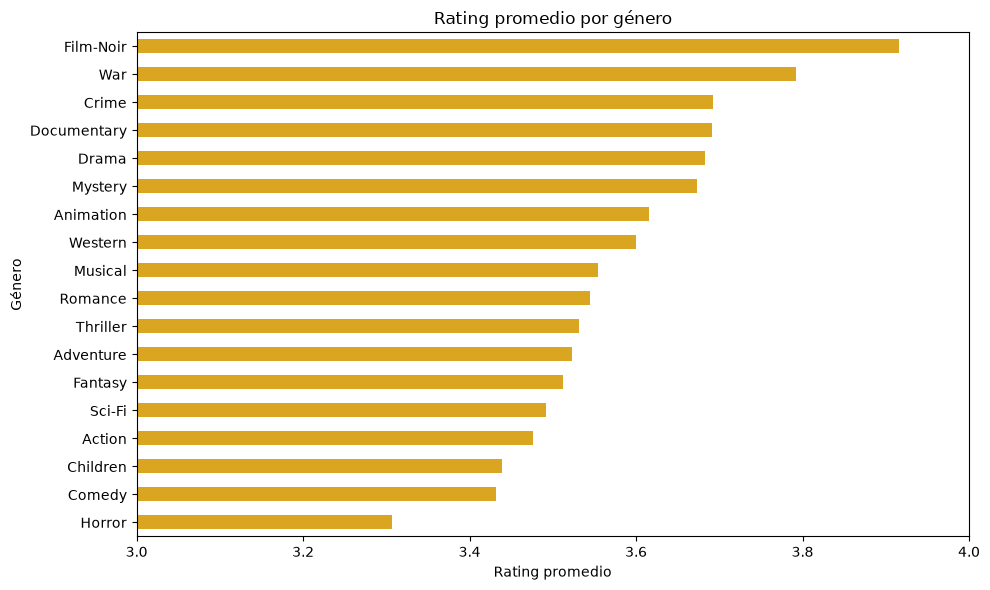

In [21]:
plt.figure(figsize=(10, 6))
rating_por_genero_df['rating_promedio'].plot(kind='barh', color='goldenrod')
plt.xlabel('Rating promedio')
plt.ylabel('Género')
plt.title('Rating promedio por género')
plt.xlim(3, 4)  # todos los promedios están entre 3.3 y 3.9: empezar en 0 aplanaría el gráfico
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Resultados:** `Film-Noir` tiene el rating promedio más alto (3.916, sobre 304,710 calificaciones) y `Horror` el más bajo (3.307, sobre 2,490,364 calificaciones). El rango entre el género mejor y peor calificado es de apenas 0.609 puntos sobre una escala de 4.5 puntos posibles (0.5 a 5.0). La desviación estándar dentro de cada género (0.91 a 1.13) es mucho mayor que la diferencia entre géneros, y géneros "serios" o de nicho (Film-Noir, War, Crime, Documentary, Drama) tienden a estar en la parte alta, mientras que géneros más orientados a entretenimiento masivo/infantil (Comedy, Children, Horror) están en la parte baja.


### Rating promedio por década de la película

**¿Qué se está calculando?** Cantidad de calificaciones, rating promedio y desviación estándar, agrupando las calificaciones por la década en que se estrenó la película calificada (no la década en que se calificó).

In [22]:
rating_por_decada = movies_ratings.groupby('decada_pelicula')['rating'].agg(['count', 'mean', 'std']).round(3)
print(rating_por_decada)

                    count   mean    std
decada_pelicula                        
1870                   67  3.172  1.208
1880                  172  2.570  1.059
1890                 1803  2.805  1.103
1900                 2854  3.326  1.074
1910                 4465  3.109  1.106
1920                49329  3.768  1.013
1930               230389  3.787  0.986
1940               364247  3.858  0.970
1950               599223  3.845  0.959
1960               883957  3.793  0.971
1970              1540407  3.774  1.014
1980              3795506  3.579  1.040
1990             10719535  3.482  1.074
2000              8950879  3.492  1.066
2010              4547250  3.544  1.045
2020               273906  3.338  1.064


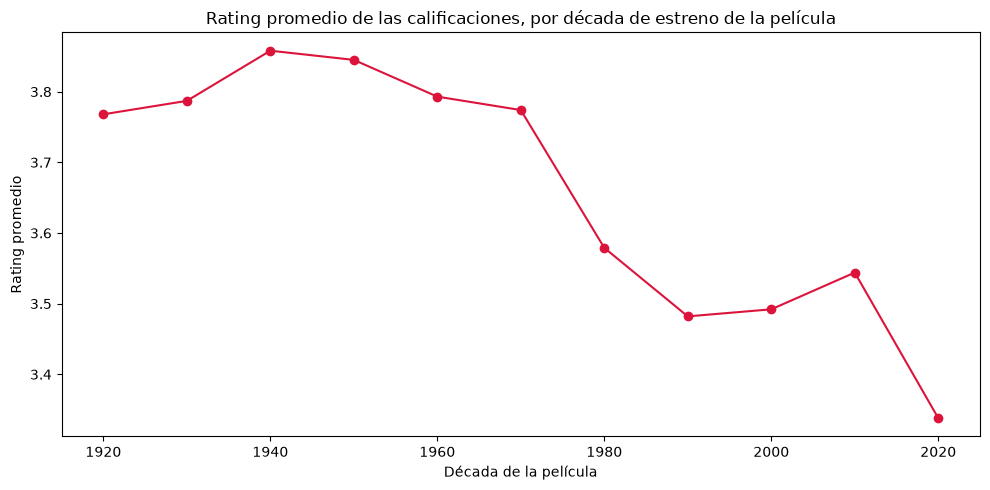

In [23]:
rating_por_decada_confiable = rating_por_decada[rating_por_decada.index >= 1920]

plt.figure(figsize=(10, 5))
plt.plot(rating_por_decada_confiable.index, rating_por_decada_confiable['mean'], marker='o', color='crimson')
plt.xlabel('Década de la película')
plt.ylabel('Rating promedio')
plt.title('Rating promedio de las calificaciones, por década de estreno de la película')
plt.tight_layout()
plt.show()

**Resultados:** las décadas anteriores a 1920 tienen muy pocas calificaciones (67 a 4,465) y ratings promedio inestables (desde 2.570 hasta 3.326) — poco confiables por tamaño de muestra. A partir de 1920 el patrón es claro: el rating promedio **sube** hasta un pico en 1940 (3.858, sobre 364,247 calificaciones) y se mantiene alto hasta 1970 (~3.77-3.85), luego **cae de forma sostenida** hasta un mínimo en 1990 (3.482), y solo repunta levemente en 2010 (3.544) antes de volver a caer en 2020 (3.338, aunque con muchas menos calificaciones todavía, 273,906).

### Relación entre popularidad y rating promedio de la película

**¿Qué se está calculando?** Por cada película: número de calificaciones recibidas (`num_ratings`) y su rating promedio (`rating_promedio`), y la correlación entre ambas variables.

In [24]:
stats_por_pelicula = movies_ratings.groupby(['movieId', 'title']).agg(
    num_ratings=('rating', 'count'),
    rating_promedio=('rating', 'mean')
).reset_index()

print(stats_por_pelicula[['num_ratings', 'rating_promedio']].describe())
print()
correlacion = stats_por_pelicula['num_ratings'].corr(stats_por_pelicula['rating_promedio'], method='spearman')
print(f"Correlación de Spearman entre num_ratings y rating_promedio: {correlacion:.3f}")

         num_ratings  rating_promedio
count   83852.000000     83852.000000
mean      381.195308         3.004978
std      2601.042893         0.800260
min         1.000000         0.500000
25%         2.000000         2.545455
50%         5.000000         3.071429
75%        25.000000         3.500000
max    102929.000000         5.000000

Correlación de Spearman entre num_ratings y rating_promedio: 0.156


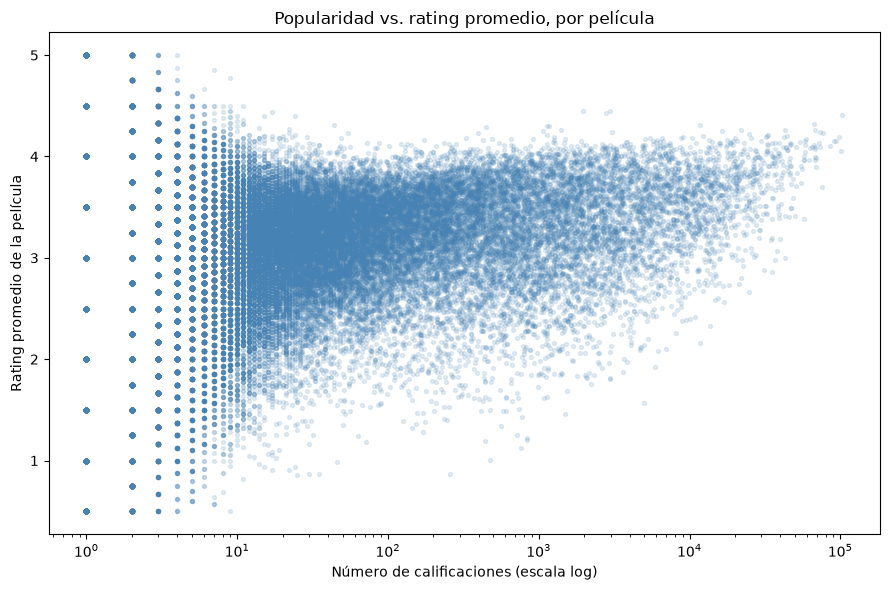

In [25]:
plt.figure(figsize=(9, 6))
plt.scatter(stats_por_pelicula['num_ratings'], stats_por_pelicula['rating_promedio'], alpha=0.15, s=8, color='steelblue')
plt.xscale('log')
plt.xlabel('Número de calificaciones (escala log)')
plt.ylabel('Rating promedio de la película')
plt.title('Popularidad vs. rating promedio, por película')
plt.tight_layout()
plt.show()

**Resultados:** hay una enorme asimetría en `num_ratings`: la mediana es de solo 5 calificaciones por película, mientras que la media es 381.2 (76 veces más), arrastrada por películas con hasta 102,929 calificaciones. El 75% de las películas tiene 25 calificaciones o menos. La correlación de Spearman entre `num_ratings` y `rating_promedio` es 0.156: positiva pero débil.

**Resultados:** hay una enorme asimetría en `num_ratings`: la mediana es de solo 5 calificaciones por película, mientras que la media es 381.2 (76 veces más), arrastrada por películas con hasta 102,929 calificaciones. El 75% de las películas tiene 25 calificaciones o menos. La correlación de Spearman entre `num_ratings` y `rating_promedio` es 0.156: positiva pero débil.

**¿Qué conclusión se obtiene?** Existe una asociación positiva leve entre qué tan calificada está una película y su rating promedio, pero es demasiado débil para decir que "las películas populares son mejores". Es más razonable interpretarlo al revés desde el punto de vista de la confiabilidad de los datos: las películas con muy pocas calificaciones (la mayoría del catálogo, mediana = 5) tienen promedios mucho más volátiles y menos representativos —una sola calificación de 0.5 o 5.0 puede mover el promedio completo—, mientras que las películas muy calificadas tienen promedios más estables porque se apoyan en una muestra grande. Esto es una limitación importante para cualquier ranking de "mejores películas": no debería hacerse sin un filtro mínimo de `num_ratings`, o el ranking estaría dominado por películas de nicho con 1 o 2 calificaciones perfectas.

Se usó correlación de **Spearman** en vez de Pearson porque `num_ratings` no tiene una relación lineal ni una distribución simétrica con `rating_promedio` — Spearman mide relación monótona basada en rangos, más robusta ante esta distribución tan sesgada.

## Hallazgos principales y conclusiones

**Lo que aporta combinar `movies` y `ratings`:**

- El merge por `movieId` (inner join) es limpio: preserva las 31,963,989 filas de `ratings` sin duplicar ni perder registros, dejando fuera únicamente las 3,115 películas del catálogo sin ninguna calificación.
- Las diferencias de rating promedio entre géneros son reales pero pequeñas (0.609 puntos entre el más alto, Film-Noir, y el más bajo, Horror), mucho menores que la variabilidad dentro de cada género.
- Las películas de décadas más antiguas (1930-1970) tienen ratings promedio más altos que las más recientes (1980-2020), un patrón mejor explicado por sesgo de supervivencia que por una caída real en la calidad del cine.
- La popularidad de una película (`num_ratings`) se asocia solo débilmente con su rating promedio (Spearman = 0.156); la mayoría de las películas tiene muy pocas calificaciones (mediana = 5), lo que hace sus promedios poco confiables individualmente.